# Ethics Data Privacy Project
### By Jennifer Panula

### Coding was performed with significant assistance from ChatGPT

In [41]:
#pip install spacy pandas


In [42]:
import sys
print(sys.executable)

C:\Users\jenpa\anaconda3\envs\py312env\python.exe


In [43]:
!{sys.executable} -m pip install spacy

In [44]:
!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----------------------- ---------------- 7.6/12.8 MB 42.7 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 38.2 MB/s  0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [45]:
import spacy
nlp = spacy.load("en_core_web_sm")
print("spaCy is working!")

spaCy is working!


In [46]:
import os
import pandas as pd

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

In [47]:
CATEGORIES = {
    "data_collection": [
        "information we collect", "data we collect", "personal information",
        "usage data", "device information", "location data"
    ],
    
    "collection_methods": [
        "cookies", "tracking technologies", "automatically collect",
        "third-party sources", "log files"
    ],
    
    "purpose_of_use": [
        "we use your information", "to provide", "to improve",
        "for marketing", "for security", "analytics"
    ],
    
    "data_sharing": [
        "third parties", "share your information", "service providers",
        "partners", "affiliates"
    ],
    
    "user_rights": [
        "access your data", "delete your data", "correct your data",
        "data portability", "your rights"
    ],
    
    "opt_out": [
        "opt out", "unsubscribe", "withdraw consent",
        "do not sell", "manage preferences"
    ],
    
    "security": [
        "security measures", "encryption", "protect your data",
        "safeguards"
    ],
    
    "data_retention": [
        "retain your data", "how long we keep",
        "data retention"
    ],
    
    "policy_updates": [
        "changes to this policy", "update this policy",
        "notify you of changes"
    ]
}

In [48]:

# Function to extract sentences by category
def extract_info(text):
    doc = nlp(text)
    results = {key: [] for key in CATEGORIES.keys()}
    
    for sent in doc.sents:
        sent_text = sent.text.lower()
        
        for category, keywords in CATEGORIES.items():
            for keyword in keywords:
                if keyword in sent_text:
                    results[category].append(sent.text.strip())
                    break
    
    return results

# Process all .txt files in data folder
def process_files(data_folder="data"):
    all_results = []
    
    for file in os.listdir(data_folder):
        if file.endswith(".txt"):
            path = os.path.join(data_folder, file)
            
            with open(path, "r", encoding="utf-8") as f:
                text = f.read()
            
            extracted = extract_info(text)
            
            row = {"service": file}
            
            for category in CATEGORIES.keys():
                row[category] = " | ".join(extracted[category][:3])  # limit output
            
            all_results.append(row)
    
    return pd.DataFrame(all_results)


# Run pipeline
df = process_files()

# Save output
df.to_csv("outputs/privacy_summary.csv", index=False)

print(df.head())

                service                                    data_collection  \
0  discover_privacy.txt  Discover Consumer Privacy Notice\nFACTS\nWHAT ...   
1      Meta_privacy.txt  Effective December 16, 2025\nRead the United S...   
2   netflix_privacy.txt  Privacy Statement\nThis Privacy Statement expl...   
3    openAI_privacy.txt  Personal Data we collect\nWe collect personal ...   

                                  collection_methods  \
0                                                      
1  Information from cookies and similar technolog...   
2  The information includes:\ndevice IDs or other...   
3  Cookies and Similar Technologies: We use cooki...   

                                      purpose_of_use  \
0                                                      
1  This Policy describes the information we, Meta...   
2  How We Use Your Personal Information\nWe use y...   
3  Location Information: We determine the general...   

                                        data_sh

In [49]:
df = pd.read_csv("outputs/privacy_summary.csv")
df.head()

,service,data_collection,collection_methods,purpose_of_use,data_sharing,user_rights,opt_out,security,data_retention,policy_updates
0,discover_privacy.txt,Discover Consumer Privacy Notice\nFACTS\nWHAT ...,NaN,NaN,For our everyday business purposes—such as to ...,See below for more on your rights under state ...,NaN,To protect your personal information from unau...,NaN,NaN
1,Meta_privacy.txt,"Effective December 16, 2025\nRead the United S...",Information from cookies and similar technolog...,"This Policy describes the information we, Meta...",Highlights\nThis Privacy Policy explains how w...,"Effective December 16, 2025\nRead the United S...",If we use your activity on our Products to tai...,Learn more about how end-to-end encryption wor...,It also describes how long we keep your inform...,We'll notify you before we make material chang...
2,netflix_privacy.txt,Privacy Statement\nThis Privacy Statement expl...,The information includes:\ndevice IDs or other...,How We Use Your Personal Information\nWe use y...,From Partners whose products and services you ...,Section B: Your Rights and Controls\nYour Priv...,"Alternatively, click the “unsubscribe” link in...",NaN,NaN,NaN
3,openAI_privacy.txt,Personal Data we collect\nWe collect personal ...,Cookies and Similar Technologies: We use cooki...,Location Information: We determine the general...,"We at OpenAI (together with our affiliates, “O...","Your rights\nDepending on where you live, you ...",Read our instructions⁠(opens in a new window) ...,"In addition, we are not responsible for circum...","For instance:\nIf specific Content, or your ac...",Changes to the privacy policy\nWe may update t...


In [50]:
def check_presence(text):
    if isinstance(text, str) and len(text.strip()) > 0:
        return "Yes"
    return "No"

In [51]:
df_reg = pd.DataFrame()

df_reg["Service"] = df["service"]

# GDPR + CCPA style checks
df_reg["Access Right"] = df["user_rights"].apply(check_presence)
df_reg["Deletion Right"] = df["user_rights"].apply(check_presence)

df_reg["Opt-Out Available"] = df["opt_out"].apply(check_presence)

df_reg["Data Sharing Disclosure"] = df["data_sharing"].apply(check_presence)

df_reg["Data Collection Transparency"] = df["data_collection"].apply(check_presence)

df_reg["Policy Update Transparency"] = df["policy_updates"].apply(check_presence)

In [52]:
def compliance_score(row):
    score = sum([
        row["Access Right"] == "Yes",
        row["Deletion Right"] == "Yes",
        row["Opt-Out Available"] == "Yes",
        row["Data Sharing Disclosure"] == "Yes",
        row["Data Collection Transparency"] == "Yes"
    ])
    return score

df_reg["Compliance Score"] = df_reg.apply(compliance_score, axis=1)

In [53]:
def compliance_note(row):
    if row["Compliance Score"] >= 4:
        return "Strong alignment with major regulations"
    elif row["Compliance Score"] >= 2:
        return "Moderate compliance, some gaps"
    else:
        return "Weak compliance, lacks transparency"

df_reg["Compliance Notes"] = df_reg.apply(compliance_note, axis=1)

In [54]:
def check_detailed(text):
    if not isinstance(text, str) or text.strip() == "":
        return "No"
    elif len(text.split()) < 10:
        return "Partial"
    else:
        return "Yes"

In [55]:
df_comp = pd.DataFrame()

df_comp["Service"] = df["service"]

df_comp["Data Collection"] = df["data_collection"].apply(check_detailed)
df_comp["Data Sharing"] = df["data_sharing"].apply(check_detailed)
df_comp["User Rights"] = df["user_rights"].apply(check_detailed)
df_comp["Opt-Out"] = df["opt_out"].apply(check_detailed)
df_comp["Security"] = df["security"].apply(check_detailed)

In [56]:
def user_friendliness(text):
    if not isinstance(text, str) or text.strip() == "":
        return "Poor"
    elif len(text.split()) < 40:
        return "Good"
    else:
        return "Moderate"

df_comp["User Friendliness"] = df["data_collection"].apply(user_friendliness)

In [57]:
score_map = {"No": 0, "Partial": 1, "Yes": 2}

df_numeric = df_comp.replace(score_map)

df_comp["Total Score"] = df_numeric[
    ["Data Collection", "Data Sharing", "User Rights", "Opt-Out", "Security"]
].sum(axis=1)

C:\Users\jenpa\AppData\Local\Temp\ipykernel_50892\2623308370.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_comp.replace(score_map)


In [58]:
df_comp.to_csv("outputs/comparative_analysis.csv", index=False)
df_comp

,Service,Data Collection,Data Sharing,User Rights,Opt-Out,Security,User Friendliness,Total Score
0,discover_privacy.txt,Yes,Yes,Yes,No,Yes,Moderate,8
1,Meta_privacy.txt,Yes,Yes,Yes,Yes,Yes,Moderate,10
2,netflix_privacy.txt,Yes,Yes,Yes,Yes,No,Moderate,8
3,openAI_privacy.txt,Yes,Yes,Yes,Yes,Yes,Moderate,10


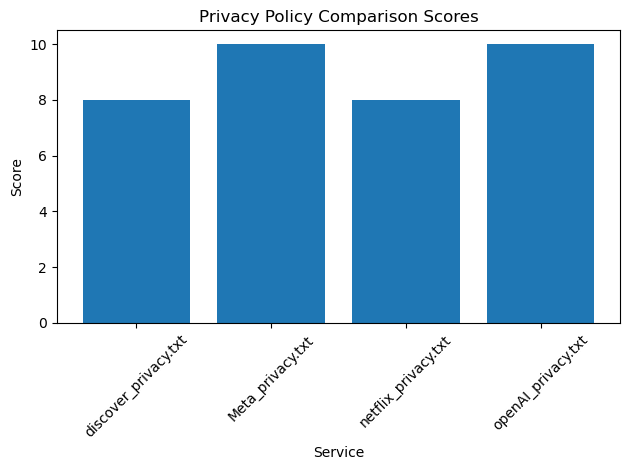

In [59]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_comp["Service"], df_comp["Total Score"])

plt.title("Privacy Policy Comparison Scores")
plt.xlabel("Service")
plt.ylabel("Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

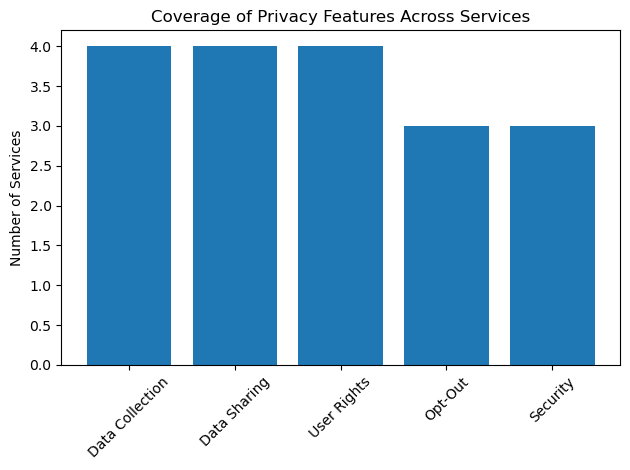

In [60]:
category_counts = {
    "Data Collection": (df_comp["Data Collection"] == "Yes").sum(),
    "Data Sharing": (df_comp["Data Sharing"] == "Yes").sum(),
    "User Rights": (df_comp["User Rights"] == "Yes").sum(),
    "Opt-Out": (df_comp["Opt-Out"] == "Yes").sum(),
    "Security": (df_comp["Security"] == "Yes").sum(),
}

plt.figure()
plt.bar(category_counts.keys(), category_counts.values())

plt.title("Coverage of Privacy Features Across Services")
plt.ylabel("Number of Services")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

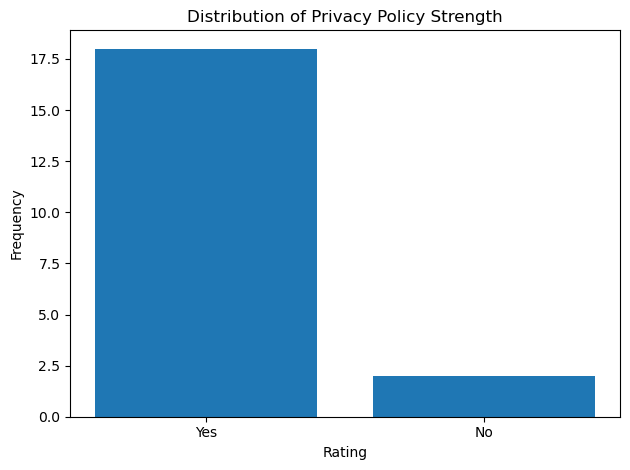

In [61]:
all_values = df_comp[
    ["Data Collection", "Data Sharing", "User Rights", "Opt-Out", "Security"]
].values.flatten()

value_counts = pd.Series(all_values).value_counts()

plt.figure()
plt.bar(value_counts.index, value_counts.values)

plt.title("Distribution of Privacy Policy Strength")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Compare agreements against key regulations

Note: this process did not use the full text of any of these laws but rather defines and answers questions such as: 

Does the company policy mention concepts like:
“right to delete”
“do not sell”
“data portability”

Those phrases = proxies for legal compliance.

- The California Consumer Privacy Act (CCPA) 
- The Virginia Consumer Data Protection Act (VCDPA)
- The General Data Protection Regulation (GDPR) 

In [62]:
REGULATORY_CATEGORIES = {
    # CCPA
    "ccpa_notice": ["categories of personal information", "sources of data", "business purpose"],
    "ccpa_opt_out_sale": ["do not sell", "opt out of sale"],
    "ccpa_access": ["request access", "right to know"],
    "ccpa_deletion": ["request deletion", "delete your information"],
    
    # VCDPA
    "vcdpa_processing_limit": ["processing purposes", "data minimization"],
    "vcdpa_rights": ["access", "correct", "delete", "portability"],
    "vcdpa_obligations": ["controller", "processor", "data protection assessment"],
    
    # GDPR
    "gdpr_consent": ["consent", "lawful basis", "legitimate interest"],
    "gdpr_data_transfer": ["international transfer", "outside the eu"],
    "gdpr_portability": ["data portability"],
    "gdpr_documentation": ["record of processing", "documentation"],
}


In [63]:
def check_keywords(text, keywords):
    if not isinstance(text, str):
        return "No"
    
    text_lower = text.lower()
    
    matches = [kw for kw in keywords if kw in text_lower]
    
    if len(matches) == 0:
        return "No"
    elif len(matches) == 1:
        return "Partial"
    else:
        return "Yes"

In [64]:
df_reg_deep = pd.DataFrame()
df_reg_deep["Service"] = df["service"]

for category, keywords in REGULATORY_CATEGORIES.items():
    df_reg_deep[category] = df.apply(
        lambda row: check_keywords(" ".join(row.astype(str)), keywords),
        axis=1
    )

In [65]:
DETAILED_FEATURES = {
    # Data Collection
    "types_of_data": ["email", "location", "device", "ip address"],
    "collection_methods": ["cookies", "tracking", "automatically"],
    "purpose_specification": ["purpose", "we use your data", "for analytics"],
    
    # User Rights
    "access_rights": ["access your data"],
    "deletion_rights": ["delete your data"],
    "portability": ["data portability"],
    "opt_out_mechanisms": ["opt out", "unsubscribe"],
    
    # Data Sharing
    "third_party_sharing": ["third parties", "partners"],
    "international_transfers": ["international transfer", "outside"],
    "service_providers": ["service providers", "vendors"],
    
    # Security
    "storage_practices": ["retain", "store"],
    "protection_methods": ["encryption", "security measures"],
    "breach_notification": ["breach", "incident notification"],
}

In [66]:
df_deep = pd.DataFrame()
df_deep["Service"] = df["service"]

for feature, keywords in DETAILED_FEATURES.items():
    df_deep[feature] = df.apply(
        lambda row: check_keywords(" ".join(row.astype(str)), keywords),
        axis=1
    )

In [67]:
feature_summary = {}

for col in df_deep.columns[1:]:
    yes_count = (df_deep[col] == "Yes").sum()
    feature_summary[col] = yes_count

common_features = [k for k, v in feature_summary.items() if v == len(df_deep)]
rare_features = [k for k, v in feature_summary.items() if v <= 1]

In [68]:
score_map = {"No": 0, "Partial": 1, "Yes": 2}

df_numeric = df_deep.replace(score_map)

df_deep["Total Score"] = df_numeric.iloc[:, 1:].sum(axis=1)

best_service = df_deep.loc[df_deep["Total Score"].idxmax()]
worst_service = df_deep.loc[df_deep["Total Score"].idxmin()]

C:\Users\jenpa\AppData\Local\Temp\ipykernel_50892\1214349204.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_deep.replace(score_map)


In [69]:
def readability_score(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())  # proxy

df["length"] = df.apply(lambda row: len(" ".join(row.astype(str)).split()), axis=1)

df_deep["User Friendliness"] = df["length"].apply(
    lambda x: "Low" if x > 5000 else "Moderate" if x > 2000 else "High"
)

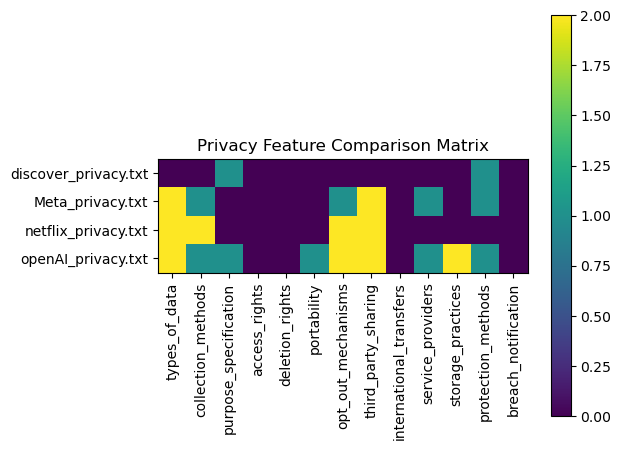

In [70]:
import matplotlib.pyplot as plt

numeric_data = df_numeric.iloc[:, 1:]

plt.figure()
plt.imshow(numeric_data.values)

plt.xticks(range(len(numeric_data.columns)), numeric_data.columns, rotation=90)
plt.yticks(range(len(df_deep["Service"])), df_deep["Service"])

plt.title("Privacy Feature Comparison Matrix")
plt.colorbar()

plt.tight_layout()
plt.show()

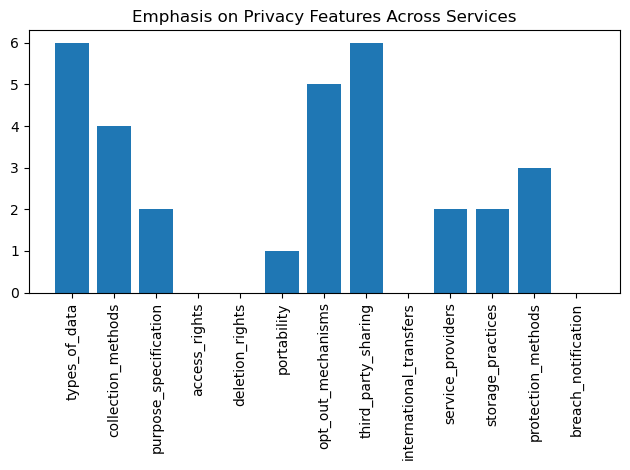

In [71]:
feature_totals = df_numeric.iloc[:, 1:].sum()

plt.figure()
plt.bar(feature_totals.index, feature_totals.values)

plt.xticks(rotation=90)
plt.title("Emphasis on Privacy Features Across Services")

plt.tight_layout()
plt.show()

In [72]:
df_deep

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Total Score,User Friendliness
0,discover_privacy.txt,No,No,Partial,No,No,No,No,No,No,No,No,Partial,No,2,High
1,Meta_privacy.txt,Yes,Partial,No,No,No,No,Partial,Yes,No,Partial,No,Partial,No,8,High
2,netflix_privacy.txt,Yes,Yes,No,No,No,No,Yes,Yes,No,No,No,No,No,8,High
3,openAI_privacy.txt,Yes,Partial,Partial,No,No,Partial,Yes,Yes,No,Partial,Yes,Partial,No,13,High


In [73]:
df_reg_deep

,Service,ccpa_notice,ccpa_opt_out_sale,ccpa_access,ccpa_deletion,vcdpa_processing_limit,vcdpa_rights,vcdpa_obligations,gdpr_consent,gdpr_data_transfer,gdpr_portability,gdpr_documentation
0,discover_privacy.txt,Partial,No,No,No,No,Partial,No,No,No,No,No
1,Meta_privacy.txt,No,No,No,No,No,No,No,No,No,No,No
2,netflix_privacy.txt,Partial,No,No,No,No,Yes,Partial,No,No,No,No
3,openAI_privacy.txt,No,No,No,No,No,Yes,No,No,No,Partial,No


In [74]:
df_numeric

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification
0,discover_privacy.txt,0,0,1,0,0,0,0,0,0,0,0,1,0
1,Meta_privacy.txt,2,1,0,0,0,0,1,2,0,1,0,1,0
2,netflix_privacy.txt,2,2,0,0,0,0,2,2,0,0,0,0,0
3,openAI_privacy.txt,2,1,1,0,0,1,2,2,0,1,2,1,0


## Analysis on Common elements and Unique Features

In [75]:
feature_presence = {}

num_services = len(df_numeric)

for col in df_numeric.columns[1:]:
    present_count = (df_numeric[col] >= 1).sum()
    feature_presence[col] = present_count

In [76]:
common_features = []
moderate_features = []
rare_features = []

for feature, count in feature_presence.items():
    if count == num_services:
        common_features.append(feature)
    elif count >= num_services / 2:
        moderate_features.append(feature)
    else:
        rare_features.append(feature)

In [77]:
summary_df = pd.DataFrame({
    "Feature": list(feature_presence.keys()),
    "Services_With_Feature": list(feature_presence.values())
})

summary_df["Category"] = summary_df["Feature"].apply(
    lambda x: "Common" if x in common_features
    else "Moderate" if x in moderate_features
    else "Rare"
)

summary_df.sort_values(by="Services_With_Feature", ascending=False, inplace=True)

summary_df

,Feature,Services_With_Feature,Category
0,types_of_data,3,Moderate
1,collection_methods,3,Moderate
11,protection_methods,3,Moderate
7,third_party_sharing,3,Moderate
6,opt_out_mechanisms,3,Moderate
2,purpose_specification,2,Moderate
9,service_providers,2,Moderate
10,storage_practices,1,Rare
5,portability,1,Rare
4,deletion_rights,0,Rare


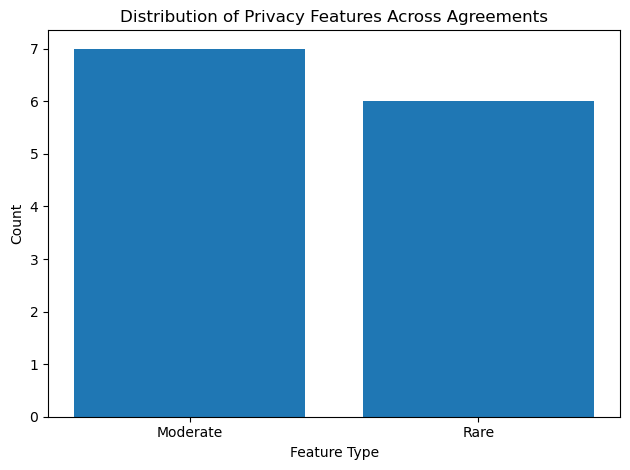

In [78]:
counts = summary_df["Category"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)

plt.title("Distribution of Privacy Features Across Agreements")
plt.xlabel("Feature Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [79]:
unique_features_detail = {}

for col in df_numeric.columns[1:]:
    services_with_feature = df_deep.loc[df_numeric[col] >= 1, "Service"].tolist()
    
    if len(services_with_feature) == 1:
        unique_features_detail[col] = services_with_feature[0]

unique_features_detail

{'portability': 'openAI_privacy.txt',
 'storage_practices': 'openAI_privacy.txt'}

In [80]:
feature_strength = df_numeric.iloc[:, 1:].mean().sort_values(ascending=False)
feature_strength

types_of_data              1.50
third_party_sharing        1.50
opt_out_mechanisms         1.25
collection_methods         1.00
protection_methods         0.75
storage_practices          0.50
service_providers          0.50
purpose_specification      0.50
portability                0.25
deletion_rights            0.00
access_rights              0.00
international_transfers    0.00
breach_notification        0.00
dtype: float64